# 03 - Preview dashboard Power BI

Este notebook no sustituye a Power BI. Sirve para ver como va quedando la historia visual del TFM antes de montar el dashboard final.

La logica de negocio que queremos mostrar es:

- volumen de ventas, costes y margen;
- rentabilidad por canal;
- categorias/productos que explican el margen;
- prediccion de unidades vendidas;
- riesgo de stock.

## 0. Preparacion

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from conexion_sql import read_sql
from eda_utils import asegurar_directorio
from visualizacion_utils import guardar_figura

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

OUT_DATOS = asegurar_directorio(PROJECT_ROOT / "outputs" / "datos")
OUT_GRAFICOS = asegurar_directorio(PROJECT_ROOT / "outputs" / "graficos")

## 1. KPIs ejecutivos

In [2]:
ventas = read_sql("SELECT * FROM gold.ventas_powerbi")
ventas["fecha"] = pd.to_datetime(ventas["fecha"])

kpis = pd.DataFrame({
    "KPI": ["Ventas netas", "Costes totales", "Margen", "Margen %", "Pedidos", "Unidades"],
    "Valor": [
        ventas["ventas_netas"].sum(),
        ventas["costes_totales"].sum(),
        ventas["margen"].sum(),
        ventas["margen"].sum() / ventas["ventas_netas"].sum(),
        ventas["id_pedido"].nunique(),
        ventas["unidades_vendidas"].sum(),
    ]
})

display(kpis)
kpis.to_csv(OUT_DATOS / "preview_kpis.csv", index=False)

G:\TFM_FINAL_VERSION_2\src\conexion_sql.py:88: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,KPI,Valor
0,Ventas netas,"6,060,400.87"
1,Costes totales,"3,948,373.08"
2,Margen,"2,112,027.79"
3,Margen %,0.35
4,Pedidos,"75,000.00"
5,Unidades,"110,250.00"


## 2. Rentabilidad por canal

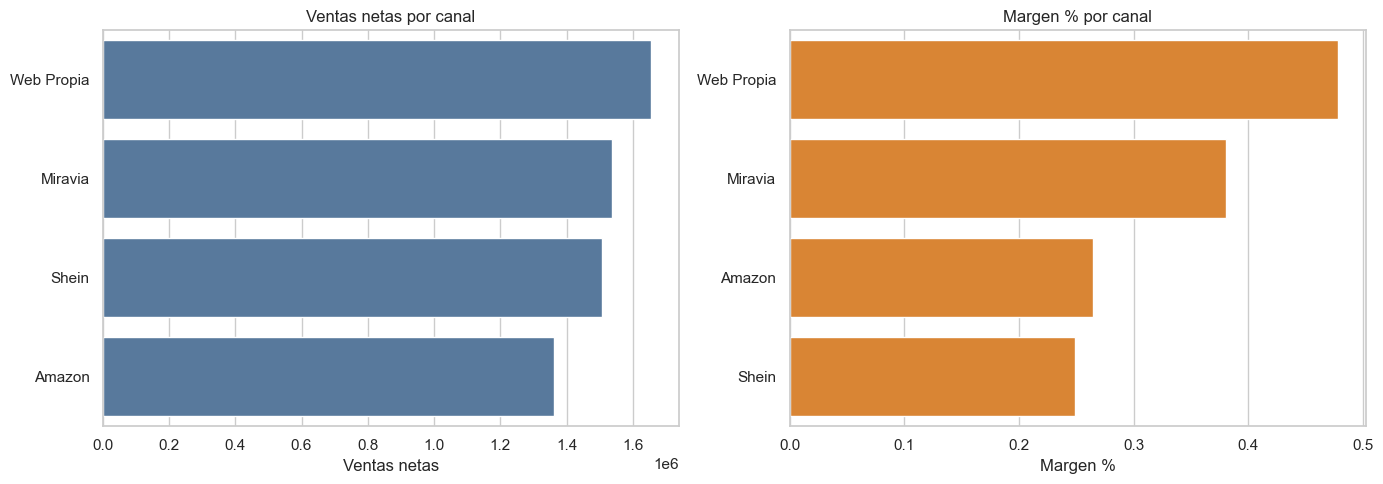

In [3]:
canal = (
    ventas.groupby("canal", as_index=False)
    .agg(ventas_netas=("ventas_netas", "sum"), margen=("margen", "sum"), comisiones=("comision", "sum"))
)
canal["margen_pct"] = canal["margen"] / canal["ventas_netas"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=canal.sort_values("ventas_netas", ascending=False), x="ventas_netas", y="canal", ax=axes[0], color="#4C78A8")
axes[0].set_title("Ventas netas por canal")
axes[0].set_xlabel("Ventas netas")
axes[0].set_ylabel("")

sns.barplot(data=canal.sort_values("margen_pct", ascending=False), x="margen_pct", y="canal", ax=axes[1], color="#F58518")
axes[1].set_title("Margen % por canal")
axes[1].set_xlabel("Margen %")
axes[1].set_ylabel("")

guardar_figura("preview_rentabilidad_canal.png", OUT_GRAFICOS)
plt.show()

## 3. Top categorias por margen

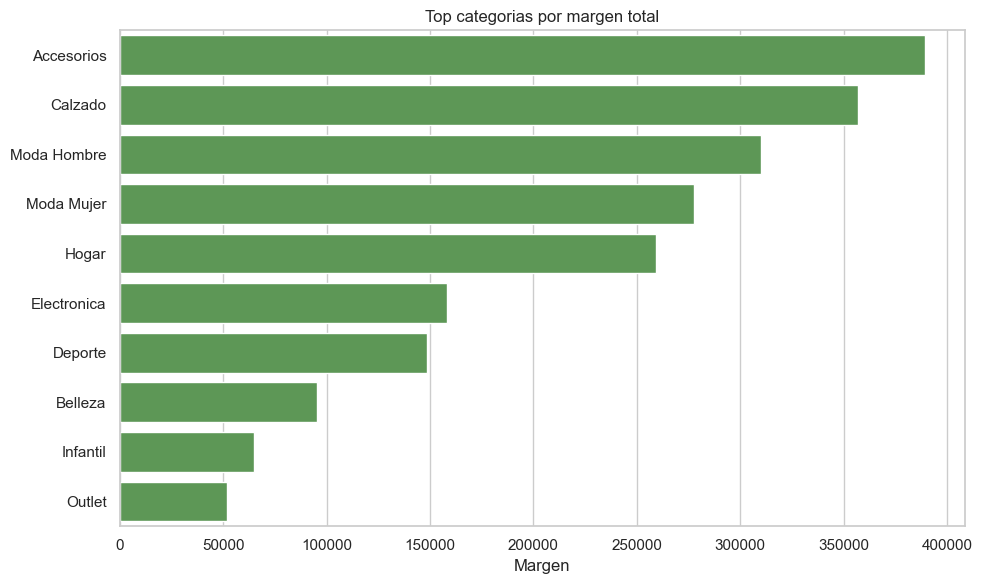

In [4]:
categoria = (
    ventas.groupby("categoria", as_index=False)
    .agg(ventas_netas=("ventas_netas", "sum"), margen=("margen", "sum"), unidades=("unidades_vendidas", "sum"))
)
categoria["margen_pct"] = categoria["margen"] / categoria["ventas_netas"]
categoria_top = categoria.sort_values("margen", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=categoria_top, x="margen", y="categoria", color="#54A24B")
plt.title("Top categorias por margen total")
plt.xlabel("Margen")
plt.ylabel("")
guardar_figura("preview_top_categorias_margen.png", OUT_GRAFICOS)
plt.show()

## 4. Prediccion de ventas si ya existe

G:\TFM_FINAL_VERSION_2\src\conexion_sql.py:88: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,fecha,canal,categoria,modelo,real,prediccion,error,error_abs
0,2025-08-13,Miravia,Moda Mujer,Baseline media movil 7d,10.00,5.71,4.29,4.29
1,2025-08-13,Amazon,Belleza,Baseline media movil 7d,18.00,7.71,10.29,10.29
2,2025-08-13,Miravia,Hogar,Baseline media movil 7d,2.00,4.29,-2.29,2.29
3,2025-08-13,Web Propia,Electronica,Baseline media movil 7d,15.00,3.00,12.00,12.00
4,2025-08-13,Amazon,Outlet,Baseline media movil 7d,5.00,2.57,2.43,2.43


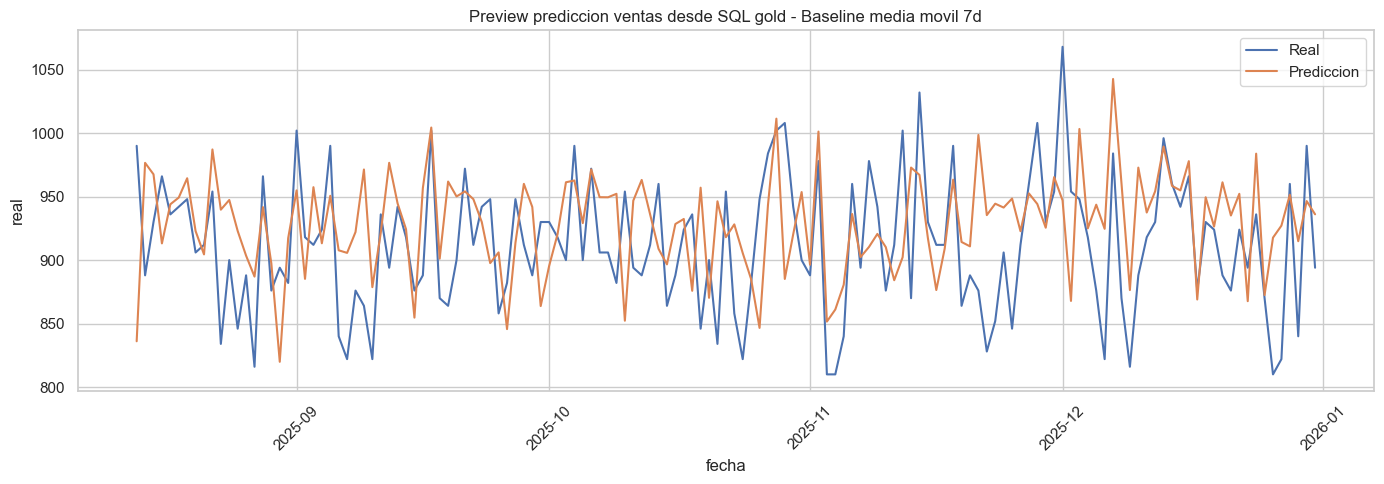

In [5]:
pred_sql = read_sql("""
SELECT
    fecha,
    canal,
    categoria,
    modelo,
    real_unidades AS real,
    prediccion_unidades AS prediccion,
    error_unidades AS error,
    error_abs_unidades AS error_abs
FROM gold.predicciones_ventas;
""")

if not pred_sql.empty:
    pred_sql["fecha"] = pd.to_datetime(pred_sql["fecha"])
    pred_fecha = pred_sql.groupby("fecha", as_index=False).agg(real=("real", "sum"), prediccion=("prediccion", "sum"))
    modelo = pred_sql["modelo"].iloc[0]

    display(pred_sql.head())

    plt.figure(figsize=(14, 5))
    sns.lineplot(data=pred_fecha, x="fecha", y="real", label="Real")
    sns.lineplot(data=pred_fecha, x="fecha", y="prediccion", label="Prediccion")
    plt.title(f"Preview prediccion ventas desde SQL gold - {modelo}")
    plt.xticks(rotation=45)
    guardar_figura("preview_prediccion_ventas.png", OUT_GRAFICOS)
    plt.show()
else:
    print("Todavia no existen predicciones en gold.fact_prediccion_ventas. Ejecuta el notebook 02 y scripts/02_export_predictions_to_sql.py.")

## 5. Riesgo de stock

G:\TFM_FINAL_VERSION_2\src\conexion_sql.py:88: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,nivel_riesgo_stock,productos_almacen
0,Sin riesgo,944
1,Riesgo alto,56


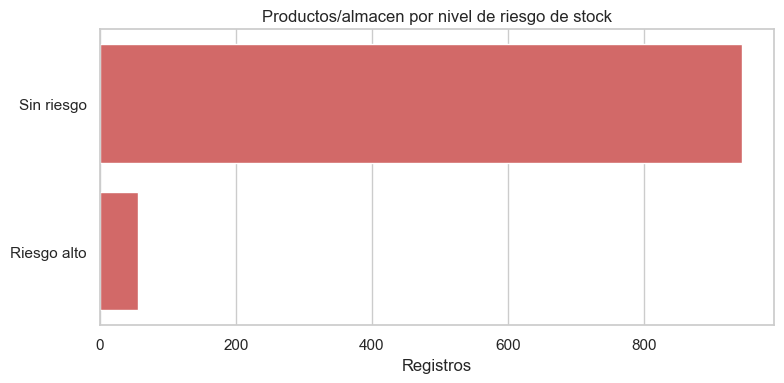

In [6]:
stock = read_sql("SELECT * FROM gold.riesgo_stock")

if "nivel_riesgo_stock" in stock.columns:
    stock_resumen = stock["nivel_riesgo_stock"].value_counts().reset_index()
    stock_resumen.columns = ["nivel_riesgo_stock", "productos_almacen"]
    display(stock_resumen)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=stock_resumen, x="productos_almacen", y="nivel_riesgo_stock", color="#E45756")
    plt.title("Productos/almacen por nivel de riesgo de stock")
    plt.xlabel("Registros")
    plt.ylabel("")
    guardar_figura("preview_riesgo_stock.png", OUT_GRAFICOS)
    plt.show()
else:
    display(stock.head())

## 6. Lectura de negocio

Esta vista previa deberia contar una historia sencilla:

1. Cuanto vendemos y cuanto margen real queda.
2. Que canales son mas rentables y cuales consumen margen.
3. Que categorias aportan mas beneficio.
4. Si el modelo predictivo anticipa razonablemente la demanda.
5. Donde hay riesgo de stock para actuar antes de perder ventas.